### Câu hỏi 1. Các công việc Data Analyst nào có mức lương cao nhất

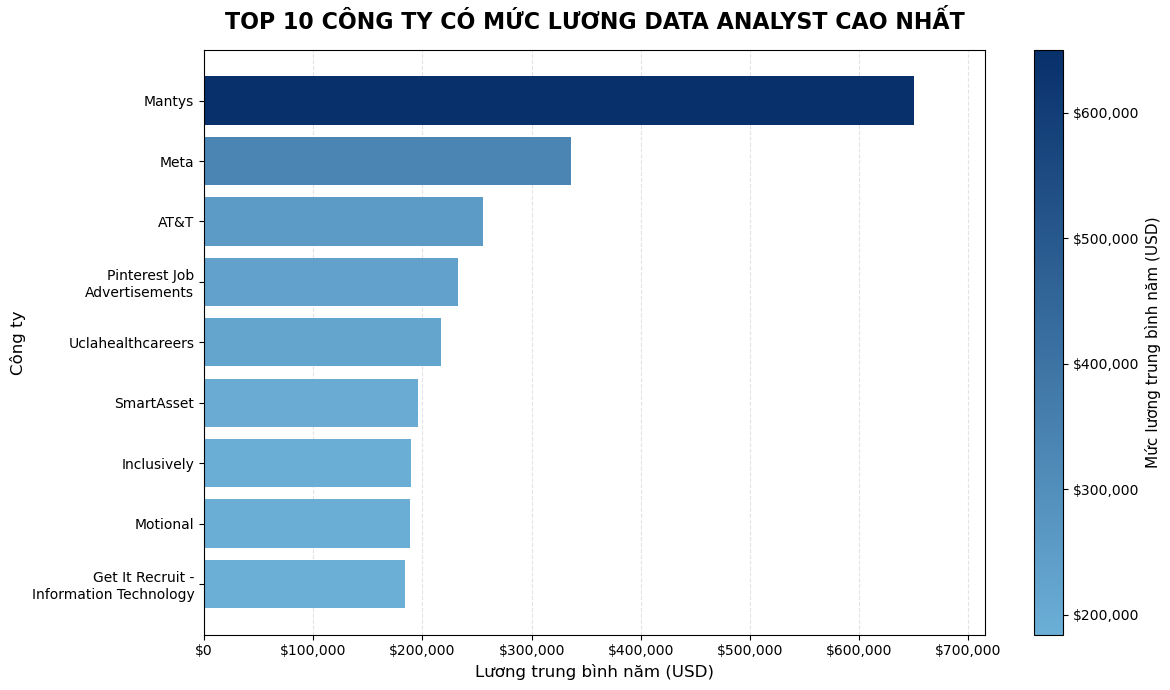

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from io import StringIO
from matplotlib.colors import Normalize, LinearSegmentedColormap
import textwrap

# =========================
# 1. Tạo DataFrame
# =========================


df = pd.read_csv(r'D:\SQL_PROJECT_DATA_JOB_ANALYSIS\csv_files\1_top_paying_job.csv')

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# =========================
# 2. Gộp lương theo công ty
# =========================

company_salary = (
    df.groupby("company_name", as_index=False)
      .agg(avg_salary=("salary_year_avg", "mean"))
      .sort_values("avg_salary", ascending=True)
)

# Xuống dòng tên công ty dài để biểu đồ đẹp hơn
company_salary["company_name_wrapped"] = company_salary["company_name"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=26))
)

# =========================
# 3. Thiết lập màu xanh -> xanh đậm
# =========================

norm = Normalize(
    vmin=company_salary["avg_salary"].min(),
    vmax=company_salary["avg_salary"].max()
)

# Tạo bảng màu riêng: xanh nhạt vừa phải -> xanh đậm
cmap = LinearSegmentedColormap.from_list(
    "custom_blue",
    ["#6BAED6", "#08306B"]   # xanh -> xanh đậm
)

colors = cmap(norm(company_salary["avg_salary"]))
# =========================
# 4. Vẽ biểu đồ
# =========================

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    company_salary["company_name_wrapped"],
    company_salary["avg_salary"],
    color=colors
)

# =========================
# 5. Định dạng biểu đồ
# =========================

ax.set_title(
    "Các công ty có mức lương cao cho vị trí Data Analyst",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Lương trung bình năm (USD)", fontsize=12)
ax.set_ylabel("Công ty", fontsize=12)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.set_xlim(0, company_salary["avg_salary"].max() * 1.1)

# =========================
# 6. Thêm thanh màu chú thích
# =========================

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)

cbar.set_label(
    "Mức lương trung bình năm (USD)",
    fontsize=11
)

cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# =========================
# 7. Hiển thị
# =========================

plt.tight_layout()

ax.set_title(
    "Top 10 công ty có mức lương Data Analyst cao nhất".upper(),
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.show()

Biểu đồ thể hiện **top 10 công ty có mức lương Data Analyst cao nhất**, trong đó Mantys nổi bật với mức lương vượt trội, còn các công ty còn lại dao động chủ yếu trong khoảng 184K–336K USD/năm.

### Câu hỏi 2. Các kỹ năng nào được yêu cầu nhiều trong các công việc lương cao? 

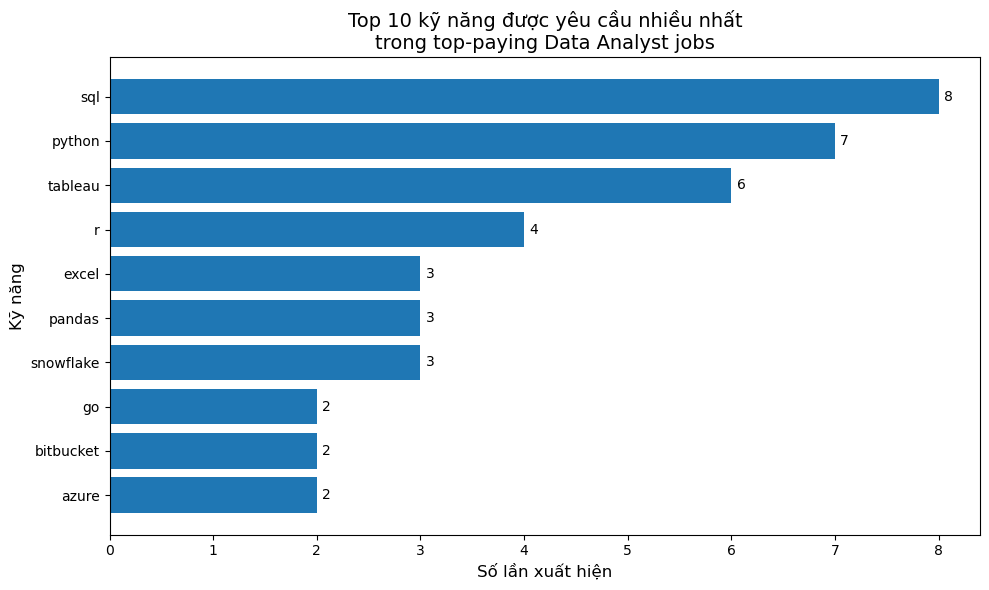

In [43]:
# =========================
# 1. Đọc dữ liệu
# =========================

df = pd.read_csv(r'D:\SQL_PROJECT_DATA_JOB_ANALYSIS\csv_files\2_top_paying_job_skills.csv')

# =========================
# 2. Đếm số lần xuất hiện của từng kỹ năng
# =========================
df["skills"] = df["skills"].str.strip().str.lower()

skill_counts = (
    df["skills"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

# =========================
# 3. Vẽ biểu đồ cột ngang
# =========================
plt.figure(figsize=(10, 6))

plt.barh(skill_counts.index, skill_counts.values)

plt.title("Top 10 kỹ năng được yêu cầu nhiều nhất\ntrong top-paying Data Analyst jobs", fontsize=14)
plt.xlabel("Số lần xuất hiện", fontsize=12)
plt.ylabel("Kỹ năng", fontsize=12)
plt.xlim(left=0)

# Gắn nhãn số ở cuối cột
for i, value in enumerate(skill_counts.values):
    plt.text(value + 0.05, i, str(value), va="center")

plt.tight_layout()
plt.show()

Biểu đồ cột ngang cho thấy **SQL** và **Python** là hai kỹ năng được yêu cầu nhiều nhất trong các top-paying Data Analyst jobs, tiếp theo là **Tableau** và **R**; điều này phản ánh nhà tuyển dụng đặc biệt ưu tiên năng lực xử lý dữ liệu, lập trình phân tích và trực quan hóa dữ liệu.

### Câu hỏi 3: Đâu là kỹ năng cần thiết nhất cho các công việc Data Analyst

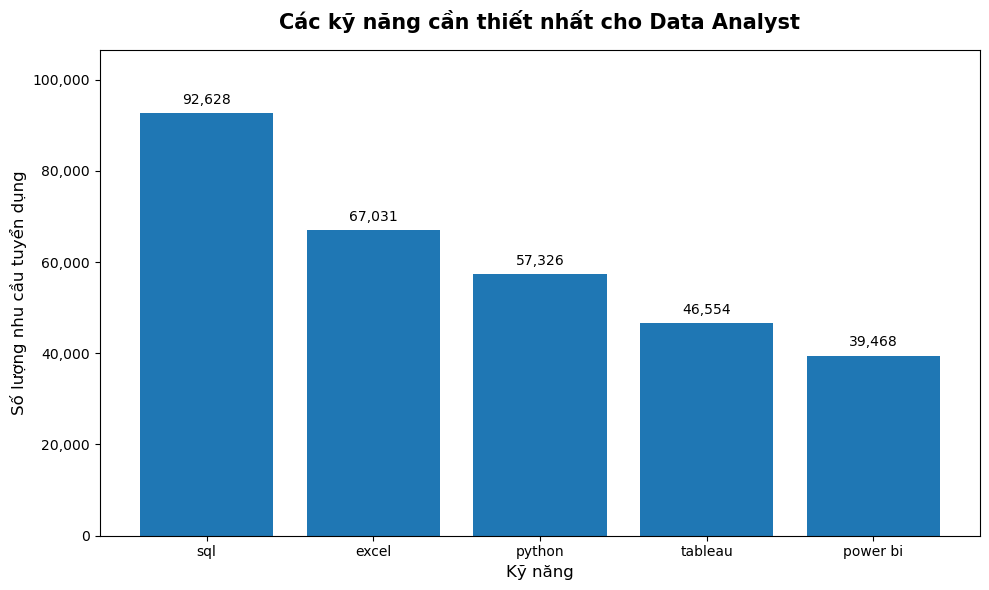

In [48]:

# =========================
# 1. Tạo dữ liệu
# =========================

df = pd.DataFrame({
    "skills": ["sql", "excel", "python", "tableau", "power bi"],
    "demand_count": [92628, 67031, 57326, 46554, 39468]
})

# Sắp xếp theo nhu cầu giảm dần
df = df.sort_values("demand_count", ascending=False)

# =========================
# 2. Vẽ biểu đồ cột
# =========================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    df["skills"],
    df["demand_count"]
)

# =========================
# 3. Định dạng biểu đồ
# =========================

plt.title(
    "Các kỹ năng cần thiết nhất cho Data Analyst",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Kỹ năng", fontsize=12)
plt.ylabel("Số lượng nhu cầu tuyển dụng", fontsize=12)

plt.ylim(0, df["demand_count"].max() * 1.15)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

# =========================
# 4. Gắn nhãn giá trị lên cột
# =========================

for bar, value in zip(bars, df["demand_count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + df["demand_count"].max() * 0.015,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Biểu đồ cho thấy **SQL** là kỹ năng được yêu cầu nhiều nhất cho vị trí Data Analyst, tiếp theo là **Excel** và **Python**, cho thấy nhà tuyển dụng ưu tiên mạnh các kỹ năng truy vấn, xử lý và phân tích dữ liệu.

### Câu hỏi 4 Kỹ năng nào được trả nhiều tiền nhất?

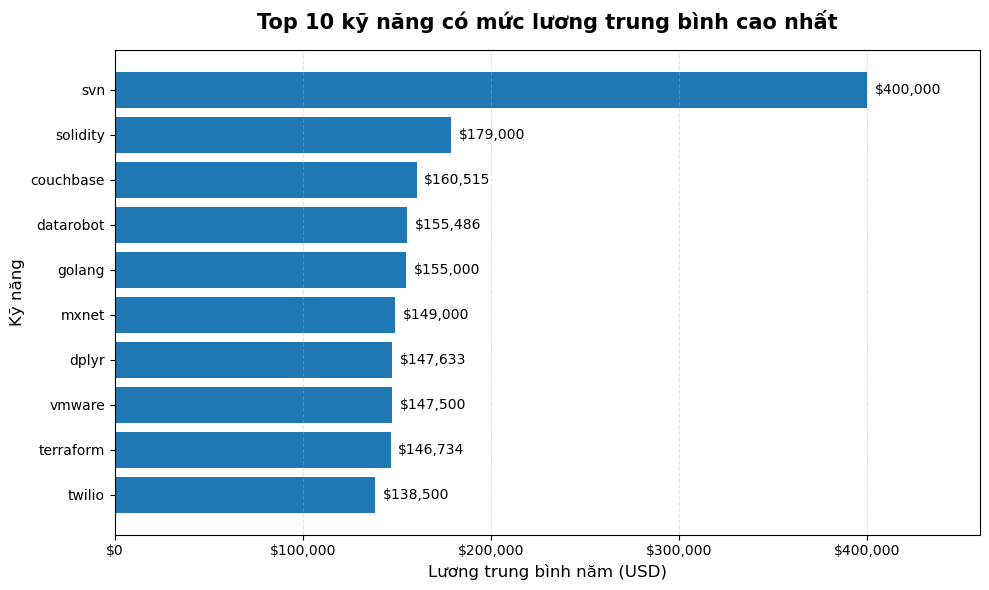

In [53]:
# =========================
# 1. Tạo dữ liệu
# =========================

df = pd.DataFrame({
    "skills": [
        "svn", "solidity", "couchbase", "datarobot", "golang",
        "mxnet", "dplyr", "vmware", "terraform", "twilio",
        "gitlab", "kafka", "puppet", "keras", "pytorch",
        "perl", "ansible", "hugging face", "tensorflow",
        "cassandra", "notion", "atlassian", "bitbucket",
        "airflow", "scala"
    ],
    "avg_salary": [
        400000.000000000000, 179000.000000000000,
        160515.000000000000, 155485.500000000000,
        155000.000000000000, 149000.000000000000,
        147633.333333333333, 147500.000000000000,
        146733.833333333333, 138500.000000000000,
        134126.000000000000, 129999.162500000000,
        129820.000000000000, 127013.333333333333,
        125226.200000000000, 124685.750000000000,
        124370.000000000000, 123950.000000000000,
        120646.833333333333, 118406.681818181818,
        118091.666666666667, 117965.600000000000,
        116711.750000000000, 116387.260563380282,
        115479.533898305085
    ]
})

# =========================
# 2. Lấy top 10 kỹ năng lương cao nhất
# =========================

top_salary_skills = (
    df.sort_values("avg_salary", ascending=False)
      .head(10)
      .sort_values("avg_salary", ascending=True)
)

# =========================
# 3. Vẽ biểu đồ cột ngang
# =========================

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_salary_skills["skills"],
    top_salary_skills["avg_salary"]
)

plt.title(
    "Top 10 kỹ năng có mức lương trung bình cao nhất",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Lương trung bình năm (USD)", fontsize=12)
plt.ylabel("Kỹ năng", fontsize=12)

plt.xlim(0, top_salary_skills["avg_salary"].max() * 1.15)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.grid(axis="x", linestyle="--", alpha=0.35)

# Gắn nhãn giá trị
for bar, value in zip(bars, top_salary_skills["avg_salary"]):
    plt.text(
        value + top_salary_skills["avg_salary"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Biểu đồ cho thấy **SVN** là kỹ năng có mức lương trung bình cao nhất, đạt khoảng **400,000 USD/năm**, cao vượt trội so với các kỹ năng còn lại. Sau SVN, các kỹ năng như **Solidity**, **Couchbase**, **DataRobot** và **Golang** cũng nằm trong nhóm kỹ năng có mức lương cao cho Data Analyst.

### Câu hỏi 5: Đâu là kỹ năng cần thiết và được trả lương cao

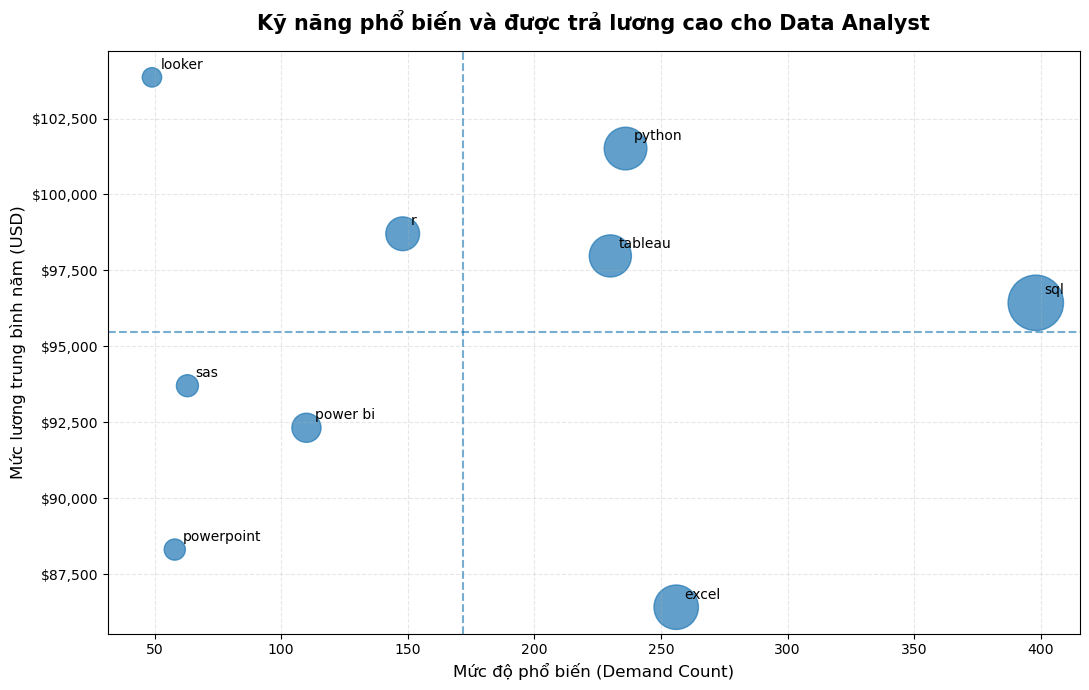

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =========================
# 1. Tạo dữ liệu
# =========================
df = pd.DataFrame({
    "skill_id": [0, 181, 1, 182, 5, 183, 7, 186, 196, 185],
    "skills": ["sql", "excel", "python", "tableau", "r", "power bi", "sas", "sas", "powerpoint", "looker"],
    "demand_count": [398, 256, 236, 230, 148, 110, 63, 63, 58, 49],
    "avg_salary": [
        96435.332040119202,
        86418.902006532898,
        101511.846673318614,
        97978.080173485533,
        98707.800763047530,
        92323.596881734914,
        93707.363179687500,
        93707.363179687500,
        88315.605245109733,
        103855.350901442308
    ]
})

# =========================
# 2. Gộp kỹ năng bị trùng
# =========================
df_plot = (
    df.groupby("skills", as_index=False)
      .agg(
          demand_count=("demand_count", "max"),
          avg_salary=("avg_salary", "mean")
      )
)

# =========================
# 3. Tính giá trị trung bình
# =========================
mean_demand = df_plot["demand_count"].mean()
mean_salary = df_plot["avg_salary"].mean()

# =========================
# 4. Vẽ biểu đồ scatter
# =========================
plt.figure(figsize=(11, 7))

# Kích thước điểm tăng theo demand_count
sizes = df_plot["demand_count"] * 4

plt.scatter(
    df_plot["demand_count"],
    df_plot["avg_salary"],
    s=sizes,
    alpha=0.7
)

# Gắn tên kỹ năng
for _, row in df_plot.iterrows():
    plt.annotate(
        row["skills"],
        (row["demand_count"], row["avg_salary"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

# Đường trung bình
plt.axvline(mean_demand, linestyle="--", alpha=0.6)
plt.axhline(mean_salary, linestyle="--", alpha=0.6)

# Định dạng trục
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))

plt.title(
    "Kỹ năng phổ biến và được trả lương cao cho Data Analyst",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Mức độ phổ biến (Demand Count)", fontsize=12)
plt.ylabel("Mức lương trung bình năm (USD)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Biểu đồ cho thấy **Python** và **Tableau** là hai kỹ năng nổi bật vì vừa có mức độ phổ biến cao vừa có mức lương trung bình cao hơn mặt bằng chung; trong khi **SQL** là kỹ năng phổ biến nhất nhưng mức lương chỉ ở mức trung bình khá, còn **Looker** có lương cao nhất nhưng mức độ phổ biến thấp hơn nhiều.